Ran on entire dataset, with smallest version of pretrained efficientnet: efficientnetb0

Imports

In [ ]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.nn.modules.batchnorm import _BatchNorm
from torch.utils.data import Subset

#data imports
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR10
import numpy as np
import time
import matplotlib.pyplot as plt
import math

# Data Preprocessing

Data Cleaning + Transformation

In [ ]:
IMG_SIZE = 32

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomCrop(IMG_SIZE, padding=4),   # augmentation
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                  # convert image → tensor
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),          # mean (standard for CIFAR-10)
        (0.2023, 0.1994, 0.2010)           # std (standard for CIFAR-10)
    )
])

transform_test = transforms.Compose([
 #   transforms.RandomCrop(IMG_SIZE, padding=4),   # augmentation
  #  transforms.RandomHorizontalFlip(),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

Data Import

In [ ]:
# CIFAR-10

train_dataset_10 = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset_10 = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


In [ ]:
def check_dataset(dataset):
    for img, label in dataset:
        if img.shape != (3, IMG_SIZE, IMG_SIZE):
            print("Bad image shape:", img.shape)
        if label not in range(10):
            print("Invalid label:", label)

check_dataset(train_dataset_10)

Selecting a subsection of the data

In [ ]:
# CIFAR 10

# Take the first N samples from each split
#N_TRAIN = 10000
#N_TEST  = 2000

#train_dataset_10 = Subset(train_dataset_10, indices=range(N_TRAIN))
#test_dataset_10  = Subset(test_dataset_10,  indices=range(N_TEST))


Loading the Data

In [ ]:
# Appendix C.2 says that a batch size of 1024 was used
BS = 1024

#CIFAR-10

train_loader_10 = DataLoader(
    train_dataset_10,
    batch_size=BS,
    shuffle=True,
    num_workers=2
)

test_loader_10 = DataLoader(
    test_dataset_10,
    batch_size=BS,
    shuffle=False,
    num_workers=2
)

print("Train:", len(train_dataset_10))
print("Test:", len(test_dataset_10))


Train: 50000
Test: 10000


View Data CIFAR 10

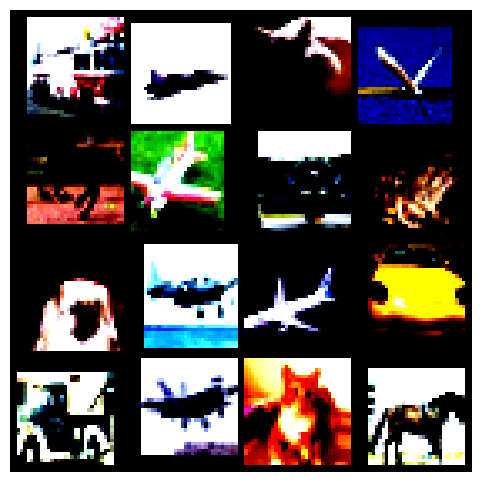

In [ ]:
import matplotlib.pyplot as plt
import torchvision

# get one batch
data_iter = iter(train_loader_10)
images, labels = next(data_iter)

# create grid of images
img_grid = torchvision.utils.make_grid(images[:16], nrow=4)

# convert tensor → numpy
img = img_grid.numpy()

# plot
plt.figure(figsize=(6,6))
plt.imshow(img.transpose((1,2,0)))
plt.axis("off")
plt.show()

# Baseline Model Implementation

## SGD

Imported pretrained model

In [ ]:
def efficientnet_b0_model(classes_num):
    # load default efficient net b7 weights
    weights = EfficientNet_B0_Weights.DEFAULT
    model = efficientnet_b0(weights=weights)

    # replace final layer so output -> correct num classes
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, classes_num)
    return model


# build model CIFAR 10
classes_num_10 = 10
model_10 = efficientnet_b0_model(classes_num_10)


# build model CIFAR 100
#classes_num_100 = 100
#model_100 = efficientnet_b0_model(classes_num_100)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 88.1MB/s]


Loss function (same used for SGD and SAM)

In [ ]:
# smooth_cross_entropy.py (from https://github.com/davda54/sam/blob/main/example/model/smooth_cross_entropy.py)

def smooth_crossentropy(pred, gold, smoothing=0.1):
    n_class = pred.size(1)

    one_hot = torch.full_like(pred, fill_value=smoothing / (n_class - 1))
    one_hot.scatter_(dim=1, index=gold.unsqueeze(1), value=1.0 - smoothing)
    log_prob = F.log_softmax(pred, dim=1)

    return F.kl_div(input=log_prob, target=one_hot, reduction='none').sum(-1)

Parameters common for both SGD and SAM.

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

num_epochs = 100

# Hyperparameters chosen from Appendix C.2

# Learning rate
LR = 0.016

# Weight Decay
WD = 1e-5

# Momentum
MT = 0.9

Training Loop (SGD)

In [ ]:
def training_loop(dataloader, model, optimizer, device):
    loss_func = nn.CrossEntropyLoss()
    model.train()

    loss_total = 0.0
    correct_count = 0
    number_samples = 0

    for images, labels in dataloader:
        # images, labels to device
        images = images.to(device)
        labels = labels.to(device)

        # gradient
        optimizer.zero_grad()
        # forward pass
        outputs = model(images)
        # compute loss
        loss = smooth_crossentropy(outputs, labels, smoothing=0.1).mean()

        loss_total += loss.item()

        # backward pass/ update model weights
        loss.backward()
        optimizer.step()

        # count correct predictions
        predictions = outputs.argmax(1)
        correct_predictions = (predictions == labels).sum().item()
        correct_count += correct_predictions

        # add size of batch
        number_samples += labels.size(0)


    # average loss and accuracy calcs
    loss_per_epoch = loss_total/len(dataloader)
    accuracy_per_epoch = correct_count/number_samples

    return loss_per_epoch, accuracy_per_epoch

In [ ]:
def save_checkpoint(state, filename="checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    torch.save(state, filename)

In [ ]:
def train_and_test_SGD(classes_num, train_loader, test_loader, LR, WD, MT):
    model = efficientnet_b0_model(classes_num).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MT, weight_decay=WD)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    sgd_train_loss = []
    sgd_test_acc = []
    best_test_acc = 0
    epoch_times = []

    for epoch in range(num_epochs):
        start_time = time.time()

        # Train
        model.train()
        training_loss, _ = training_loop(train_loader, model, optimizer, device)
        sgd_train_loss.append(training_loss)
        scheduler.step()

        # Test
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                predictions = model(inputs)
                correct += (predictions.argmax(1) == targets).sum().item()
                total += targets.size(0)

        # Recording testing accuracy per epoch
        test_acc = correct / total
        sgd_test_acc.append(correct / total)

        if test_acc > best_test_acc:
            best_test_acc = test_acc

        epoch_time = time.time() - start_time
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {training_loss:.4f}, Test Accuracy: {correct / total:.4f}")

    avg_time = sum(epoch_times) / len(epoch_times)
    print(f"Average time per epoch: {avg_time:.2f}s")

    checkpoint = {
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            }

    checkpoint_filename = f"checkpoint_CIFAR{classes_num}_SGD.pth.tar"
    save_checkpoint(checkpoint, filename =checkpoint_filename)

    print("Best test accuracy for SGD", best_test_acc)

    return sgd_train_loss, sgd_test_acc, model

In [ ]:
# Training and testing SGD on CIFAR 10
sgd_train_loss_10, sgd_test_acc_10, model = train_and_test_SGD(classes_num_10, train_loader_10, test_loader_10, LR, WD, MT)

Epoch 1/100 - Training Loss: 1.4567, Test Accuracy: 0.4785
Epoch 2/100 - Training Loss: 1.0178, Test Accuracy: 0.5802
Epoch 3/100 - Training Loss: 0.8378, Test Accuracy: 0.6647
Epoch 4/100 - Training Loss: 0.7238, Test Accuracy: 0.6972
Epoch 5/100 - Training Loss: 0.6535, Test Accuracy: 0.7283
Epoch 6/100 - Training Loss: 0.5966, Test Accuracy: 0.7434
Epoch 7/100 - Training Loss: 0.5643, Test Accuracy: 0.7554
Epoch 8/100 - Training Loss: 0.5315, Test Accuracy: 0.7674
Epoch 9/100 - Training Loss: 0.5058, Test Accuracy: 0.7766
Epoch 10/100 - Training Loss: 0.4826, Test Accuracy: 0.7826
Epoch 11/100 - Training Loss: 0.4639, Test Accuracy: 0.7867
Epoch 12/100 - Training Loss: 0.4493, Test Accuracy: 0.7965
Epoch 13/100 - Training Loss: 0.4344, Test Accuracy: 0.8016
Epoch 14/100 - Training Loss: 0.4178, Test Accuracy: 0.8043
Epoch 15/100 - Training Loss: 0.4064, Test Accuracy: 0.8093
Epoch 16/100 - Training Loss: 0.3961, Test Accuracy: 0.8124
Epoch 17/100 - Training Loss: 0.3861, Test Accura

## SAM

https://github.com/davda54/sam/blob/main/sam.py

In [ ]:
# sam.py (from https://github.com/davda54/sam/blob/main/sam.py)

class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, adaptive=False, **kwargs):
        assert rho >= 0.0, f"Invalid rho, should be non-negative: {rho}"

        defaults = dict(rho=rho, adaptive=adaptive, **kwargs)
        super(SAM, self).__init__(params, defaults)

        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)

            for p in group["params"]:
                if p.grad is None: continue
                self.state[p]["old_p"] = p.data.clone()
                e_w = (torch.pow(p, 2) if group["adaptive"] else 1.0) * p.grad * scale.to(p)
                p.add_(e_w)

        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None: continue
                p.data = self.state[p]["old_p"]

        self.base_optimizer.step()

        if zero_grad: self.zero_grad()

    @torch.no_grad()
    def step(self, closure=None):
        assert closure is not None, "Sharpness Aware Minimization requires closure, but it was not provided"
        closure = torch.enable_grad()(closure)

        self.first_step(zero_grad=True)
        closure()
        self.second_step()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(
                    torch.stack([
                        ((torch.abs(p) if group["adaptive"] else 1.0) * p.grad).norm(p=2).to(shared_device)
                        for group in self.param_groups for p in group["params"]
                        if p.grad is not None
                    ]),
                    p=2
               )
        return norm

    def load_state_dict(self, state_dict):
        super().load_state_dict(state_dict)
        self.base_optimizer.param_groups = self.param_groups

In [ ]:
# bypass_bn.py (from https://github.com/davda54/sam/blob/main/example/utility/bypass_bn.py)

def disable_running_stats(model):
    def _disable(module):
        if isinstance(module, _BatchNorm):
            module.backup_momentum = module.momentum
            module.momentum = 0

    model.apply(_disable)

def enable_running_stats(model):
    def _enable(module):
        if isinstance(module, _BatchNorm) and hasattr(module, "backup_momentum"):
            module.momentum = module.backup_momentum

    model.apply(_enable)

Training Loop (SAM)

In [ ]:
def train_and_test_SAM(classes_num, train_loader, test_loader, LR, WD, MT):
  # Training loop from https://github.com/davda54/sam/blob/main/example/train.py

  model = efficientnet_b0_model(classes_num).to(device)

  optimizer = SAM(model.parameters(), torch.optim.SGD, rho=0.05, lr=LR, momentum=MT, weight_decay=WD)

  # cosine scheduler
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer.base_optimizer, T_max=num_epochs)

  sam_train_loss= []
  sam_test_acc  = []
  best_test_acc = 0
  epoch_times = []

  for epoch in range(num_epochs):
      start_time = time.time()

      model.train()

      loss_total = 0.0

      for batch in train_loader:
          inputs, targets = (b.to(device) for b in batch)

          # first forward-backward step
          enable_running_stats(model)
          predictions = model(inputs)
          loss = smooth_crossentropy(predictions, targets, smoothing=0.1).mean()
          loss_total += loss.item()
          loss.backward()
          optimizer.first_step(zero_grad=True)

          # second forward-backward step
          disable_running_stats(model)
          smooth_crossentropy(model(inputs), targets, smoothing=0.1).mean().backward()
          optimizer.second_step(zero_grad=True)


      scheduler.step()

      # Recording training loss of SAM per epoch
      sam_train_loss.append(loss_total/len(train_loader))

      # === TEST after this epoch ===
      model.eval()
      correct, total = 0, 0
      with torch.no_grad():
          for inputs, targets in test_loader:
              inputs, targets = inputs.to(device), targets.to(device)
              predictions = model(inputs)
              correct += (predictions.argmax(1) == targets).sum().item()
              total += targets.size(0)

      # Recording testing accuracy per epoch
      test_acc = correct / total

      if test_acc > best_test_acc:
          best_test_acc = test_acc

      sam_test_acc.append(correct/total)

      epoch_time = time.time() - start_time
      epoch_times.append(epoch_time)

      print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {loss_total/len(train_loader):.4f} | Test Accuracy: {correct/total:.4f}")

  # Print average time at the end
  avg_time = sum(epoch_times) / len(epoch_times)
  print(f"Average time per epoch: {avg_time:.2f}s")

  checkpoint = {
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            }
  checkpoint_filename = f"checkpoint_CIFAR{classes_num}_SAM.pth.tar"
  save_checkpoint(checkpoint, filename =checkpoint_filename)

  print("Best test accuracy for SGD", best_test_acc)

  return sam_train_loss, sam_test_acc, model


In [ ]:
# Training and testing SAM on CIFAR 10
sam_train_loss_10, sam_test_acc_10, model = train_and_test_SAM(classes_num_10, train_loader_10, test_loader_10, LR, WD, MT)

Epoch 1/100 - Training Loss: 1.4485 | Test Accuracy: 0.4715
Epoch 2/100 - Training Loss: 1.0077 | Test Accuracy: 0.6010
Epoch 3/100 - Training Loss: 0.8209 | Test Accuracy: 0.6703
Epoch 4/100 - Training Loss: 0.7096 | Test Accuracy: 0.7115
Epoch 5/100 - Training Loss: 0.6426 | Test Accuracy: 0.7344
Epoch 6/100 - Training Loss: 0.5877 | Test Accuracy: 0.7493
Epoch 7/100 - Training Loss: 0.5523 | Test Accuracy: 0.7614
Epoch 8/100 - Training Loss: 0.5247 | Test Accuracy: 0.7686
Epoch 9/100 - Training Loss: 0.5030 | Test Accuracy: 0.7747
Epoch 10/100 - Training Loss: 0.4827 | Test Accuracy: 0.7845
Epoch 11/100 - Training Loss: 0.4657 | Test Accuracy: 0.7870
Epoch 12/100 - Training Loss: 0.4500 | Test Accuracy: 0.7914
Epoch 13/100 - Training Loss: 0.4348 | Test Accuracy: 0.7998
Epoch 14/100 - Training Loss: 0.4238 | Test Accuracy: 0.8003
Epoch 15/100 - Training Loss: 0.4094 | Test Accuracy: 0.8044
Epoch 16/100 - Training Loss: 0.3994 | Test Accuracy: 0.8102
Epoch 17/100 - Training Loss: 0.3

## Plots

CIFAR 10 Plots

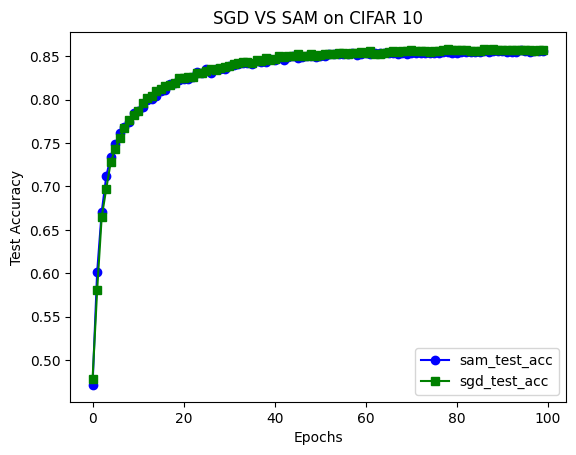

In [ ]:
x = np.arange(0, num_epochs)
sam_test_acc_y, sgd_test_acc_y = sam_test_acc_10, sgd_test_acc_10

plt.plot(x, sam_test_acc_y, color='b', label='sam_test_acc',  marker="o")
plt.plot(x, sgd_test_acc_y, color='g', label='sgd_test_acc',  marker="s")

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.title("SGD VS SAM on CIFAR 10")
plt.legend()
plt.show()

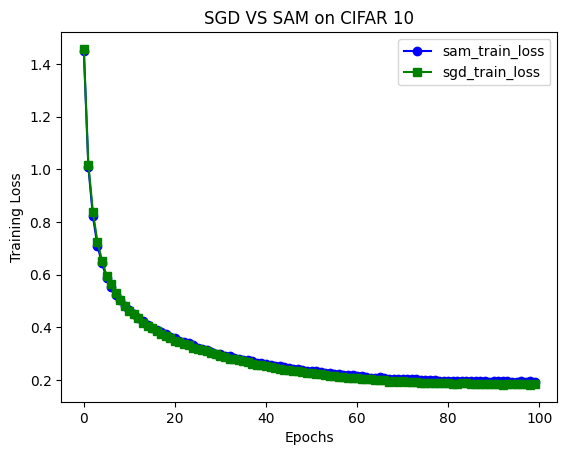

In [ ]:
x = np.arange(0, num_epochs)
sam_train_loss_y, sgd_train_loss_y = sam_train_loss_10, sgd_train_loss_10

plt.plot(x, sam_train_loss_y, color='b', label='sam_train_loss', marker="o")
plt.plot(x, sgd_train_loss_y, color='g', label='sgd_train_loss',  marker="s")

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("SGD VS SAM on CIFAR 10")
plt.legend()
plt.show()